<a href="https://colab.research.google.com/github/PETEROA/ML-Optimization-Daily/blob/main/efficiency_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Architecture Efficiency Analysis

Here i attempt to implement tools to measure, compare, and visualise architecture efficiency across multiple dimensions: parameters, FLOPs, memory, latency, throughput, and accuracy. I built a profiler that breaks down costs by layer type, identify bottlenecks, and generate efficiency reports. We compare architectures from previous days (MobileNets, EfficientNets, NAS-discovered) using consistent metrics. Finally, I create efficiency frontiers showing Pareto-optimal trade-offs.

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt
from typing import Optional, List, Dict, Tuple, Union, Any
from dataclasses import dataclass, field
from collections import defaultdict, OrderedDict
import time
import warnings
warnings.filterwarnings('ignore')

torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


In [2]:
@dataclass
class EfficiencyMetrics:
    """
    Complete efficiency metrics for an architecture.
    """
    name: str

    # Size metrics
    params: int = 0
    params_mb: float = 0.0

    # Compute metrics
    flops: int = 0
    macs: int = 0  # Multiply-accumulate operations

    # Memory metrics
    peak_memory_mb: float = 0.0
    activation_memory_mb: float = 0.0

    # Speed metrics
    latency_ms: float = 0.0
    throughput: float = 0.0  # samples/second

    # Accuracy metrics
    accuracy: float = 0.0
    top5_accuracy: float = 0.0

    # Derived efficiency metrics
    accuracy_per_param: float = 0.0
    accuracy_per_flop: float = 0.0
    accuracy_per_ms: float = 0.0

    def compute_derived(self):
        """Compute derived efficiency metrics."""
        if self.params > 0:
            self.accuracy_per_param = self.accuracy / (self.params / 1e6)
        if self.flops > 0:
            self.accuracy_per_flop = self.accuracy / (self.flops / 1e9)
        if self.latency_ms > 0:
            self.accuracy_per_ms = self.accuracy / self.latency_ms

    def __repr__(self):
        return (f"EfficiencyMetrics({self.name}: "
                f"{self.params/1e6:.2f}M params, "
                f"{self.flops/1e9:.2f}G FLOPs, "
                f"{self.latency_ms:.2f}ms, "
                f"{100*self.accuracy:.1f}% acc)")

Architecture Profiler

A profiler that measures all efficiency dimensions.

In [3]:
@dataclass
class LayerProfile:
    """Profile for a single layer."""
    name: str
    layer_type: str
    params: int = 0
    flops: int = 0
    input_shape: Tuple = ()
    output_shape: Tuple = ()
    memory_mb: float = 0.0
    latency_ms: float = 0.0


class ArchitectureProfiler:
    """
    Comprehensive architecture profiler.

    Measures:
    - Parameters per layer
    - FLOPs per layer
    - Memory per layer
    - Latency breakdown
    """

    def __init__(self, model: nn.Module, input_size: Tuple[int, ...] = (1, 3, 224, 224)):
        self.model = model
        self.input_size = input_size
        self.layer_profiles: List[LayerProfile] = []
        self.hooks = []

    def _get_layer_type(self, module: nn.Module) -> str:
        """Get human-readable layer type."""
        type_name = type(module).__name__
        if isinstance(module, nn.Conv2d):
            k = module.kernel_size[0]
            if module.groups == module.in_channels:
                return f'DWConv{k}x{k}'
            elif k == 1:
                return 'Conv1x1'
            else:
                return f'Conv{k}x{k}'
        return type_name

    def _compute_conv_flops(self, module: nn.Conv2d, output: torch.Tensor) -> int:
        """Compute FLOPs for Conv2d."""
        out_h, out_w = output.shape[2], output.shape[3]
        flops = 2 * module.out_channels * out_h * out_w * \
                (module.in_channels // module.groups) * \
                module.kernel_size[0] * module.kernel_size[1]
        return flops

    def _compute_linear_flops(self, module: nn.Linear) -> int:
        """Compute FLOPs for Linear."""
        return 2 * module.in_features * module.out_features

    def _compute_bn_flops(self, module: nn.BatchNorm2d, output: torch.Tensor) -> int:
        """Compute FLOPs for BatchNorm."""
        return 4 * output.numel()  # mean, var, normalize, scale

    def _register_hooks(self):
        """Register forward hooks on all layers."""

        def hook_fn(name):
            def hook(module, input, output):
                # Get shapes
                if isinstance(input, tuple):
                    input_shape = tuple(input[0].shape) if len(input) > 0 else ()
                else:
                    input_shape = tuple(input.shape)

                if isinstance(output, tuple):
                    output_shape = tuple(output[0].shape) if len(output) > 0 else ()
                else:
                    output_shape = tuple(output.shape)

                # Count parameters
                params = sum(p.numel() for p in module.parameters(recurse=False))

                # Compute FLOPs
                flops = 0
                if isinstance(module, nn.Conv2d):
                    flops = self._compute_conv_flops(module, output)
                elif isinstance(module, nn.Linear):
                    flops = self._compute_linear_flops(module)
                elif isinstance(module, (nn.BatchNorm2d, nn.BatchNorm1d)):
                    flops = self._compute_bn_flops(module, output)

                # Memory (activation size in MB)
                if isinstance(output, torch.Tensor):
                    memory_mb = output.numel() * 4 / (1024 ** 2)  # float32
                else:
                    memory_mb = 0

                profile = LayerProfile(
                    name=name,
                    layer_type=self._get_layer_type(module),
                    params=params,
                    flops=flops,
                    input_shape=input_shape,
                    output_shape=output_shape,
                    memory_mb=memory_mb
                )
                self.layer_profiles.append(profile)

            return hook

        # Register on leaf modules
        for name, module in self.model.named_modules():
            if len(list(module.children())) == 0:  # Leaf module
                h = module.register_forward_hook(hook_fn(name))
                self.hooks.append(h)

    def _remove_hooks(self):
        """Remove all hooks."""
        for h in self.hooks:
            h.remove()
        self.hooks = []

    def profile(self) -> EfficiencyMetrics:
        """
        Run full profiling.
        """
        self.layer_profiles = []
        self.model.eval()

        # Register hooks
        self._register_hooks()

        # Forward pass
        x = torch.randn(self.input_size)

        with torch.no_grad():
            _ = self.model(x)

        # Remove hooks
        self._remove_hooks()

        # Aggregate metrics
        total_params = sum(p.params for p in self.layer_profiles)
        total_flops = sum(p.flops for p in self.layer_profiles)
        total_memory = sum(p.memory_mb for p in self.layer_profiles)

        metrics = EfficiencyMetrics(
            name=type(self.model).__name__,
            params=total_params,
            params_mb=total_params * 4 / (1024 ** 2),
            flops=total_flops,
            macs=total_flops // 2,
            activation_memory_mb=total_memory
        )

        return metrics

    def get_layer_breakdown(self) -> Dict[str, Dict]:
        """
        Get breakdown by layer type.
        """
        breakdown = defaultdict(lambda: {'count': 0, 'params': 0, 'flops': 0, 'memory': 0})

        for profile in self.layer_profiles:
            layer_type = profile.layer_type
            breakdown[layer_type]['count'] += 1
            breakdown[layer_type]['params'] += profile.params
            breakdown[layer_type]['flops'] += profile.flops
            breakdown[layer_type]['memory'] += profile.memory_mb

        return dict(breakdown)

    def print_summary(self):
        """Print profiling summary."""
        metrics = self.profile()
        breakdown = self.get_layer_breakdown()

        print(f"\n{'='*70}")
        print(f"Architecture Profile: {metrics.name}")
        print(f"{'='*70}")

        print(f"\nOverall Metrics:")
        print(f"  Parameters: {metrics.params:,} ({metrics.params_mb:.2f} MB)")
        print(f"  FLOPs: {metrics.flops:,} ({metrics.flops/1e9:.2f} GFLOPs)")
        print(f"  Activation Memory: {metrics.activation_memory_mb:.2f} MB")

        print(f"\nLayer Type Breakdown:")
        print(f"{'Type':<20} {'Count':>8} {'Params':>12} {'FLOPs':>12} {'Memory':>10}")
        print("-" * 65)

        for layer_type, stats in sorted(breakdown.items(),
                                        key=lambda x: x[1]['flops'], reverse=True):
            print(f"{layer_type:<20} {stats['count']:>8} "
                  f"{stats['params']:>12,} {stats['flops']:>12,} "
                  f"{stats['memory']:>9.2f}MB")

        return metrics

In [4]:
# Test profiler with a simple model

class SimpleNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 64, 3, stride=2, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.conv3 = nn.Conv2d(64, 128, 3, stride=2, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Linear(128, 10)

    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        x = F.relu(self.bn3(self.conv3(x)))
        x = self.pool(x)
        x = x.view(x.size(0), -1)
        return self.fc(x)

model = SimpleNet()
profiler = ArchitectureProfiler(model, input_size=(1, 3, 32, 32))
metrics = profiler.print_summary()


Architecture Profile: SimpleNet

Overall Metrics:
  Parameters: 94,986 (0.36 MB)
  FLOPs: 20,875,776 (0.02 GFLOPs)
  Activation Memory: 0.44 MB

Layer Type Breakdown:
Type                    Count       Params        FLOPs     Memory
-----------------------------------------------------------------
Conv3x3                     3       93,248   20,643,840      0.22MB
BatchNorm2d                 3          448      229,376      0.22MB
Linear                      1        1,290        2,560      0.00MB
AdaptiveAvgPool2d           1            0            0      0.00MB


Layer-wise Analysis

Analysis of where computation and parameters are spent.

In [5]:
class LayerAnalyzer:
    """
    Analyze layer-wise distribution of resources.
    """

    def __init__(self, profiler: ArchitectureProfiler):
        self.profiler = profiler

    def get_cumulative_distribution(self, metric: str = 'flops') -> List[Tuple[str, float]]:
        """
        Get cumulative distribution of a metric across layers.
        """
        total = sum(getattr(p, metric) for p in self.profiler.layer_profiles)
        if total == 0:
            return []

        cumulative = []
        running_sum = 0

        for profile in self.profiler.layer_profiles:
            value = getattr(profile, metric)
            running_sum += value
            cumulative.append((profile.name, running_sum / total))

        return cumulative

    def find_bottlenecks(self, metric: str = 'flops', top_k: int = 5) -> List[LayerProfile]:
        """
        Find top-k layers consuming most of a resource.
        """
        sorted_layers = sorted(self.profiler.layer_profiles,
                              key=lambda x: getattr(x, metric),
                              reverse=True)
        return sorted_layers[:top_k]

    def compute_efficiency_ratio(self) -> Dict[str, float]:
        """
        Compute efficiency ratios for different layer types.

        Efficiency = FLOPs / Parameters (higher = more compute per param)
        """
        breakdown = self.profiler.get_layer_breakdown()

        ratios = {}
        for layer_type, stats in breakdown.items():
            if stats['params'] > 0:
                ratios[layer_type] = stats['flops'] / stats['params']
            else:
                ratios[layer_type] = 0

        return ratios

    def visualize_distribution(self, save_path: str = None):
        """
        Visualize resource distribution.
        """
        fig, axes = plt.subplots(2, 2, figsize=(14, 10))

        breakdown = self.profiler.get_layer_breakdown()
        layer_types = list(breakdown.keys())

        # Plot 1: Parameters by layer type
        ax = axes[0, 0]
        params = [breakdown[lt]['params'] for lt in layer_types]
        colors = plt.cm.Set3(np.linspace(0, 1, len(layer_types)))
        ax.pie(params, labels=layer_types, autopct='%1.1f%%', colors=colors)
        ax.set_title('Parameters by Layer Type')

        # Plot 2: FLOPs by layer type
        ax = axes[0, 1]
        flops = [breakdown[lt]['flops'] for lt in layer_types]
        ax.pie(flops, labels=layer_types, autopct='%1.1f%%', colors=colors)
        ax.set_title('FLOPs by Layer Type')

        # Plot 3: Layer-wise FLOPs
        ax = axes[1, 0]
        layer_names = [p.name[-20:] for p in self.profiler.layer_profiles]  # Truncate names
        layer_flops = [p.flops / 1e6 for p in self.profiler.layer_profiles]

        if len(layer_names) > 20:  # Too many layers, show top 20
            sorted_idx = np.argsort(layer_flops)[-20:]
            layer_names = [layer_names[i] for i in sorted_idx]
            layer_flops = [layer_flops[i] for i in sorted_idx]

        ax.barh(range(len(layer_names)), layer_flops, color='steelblue')
        ax.set_yticks(range(len(layer_names)))
        ax.set_yticklabels(layer_names, fontsize=8)
        ax.set_xlabel('MFLOPs')
        ax.set_title('FLOPs by Layer (Top 20)')

        # Plot 4: Cumulative FLOPs
        ax = axes[1, 1]
        cumulative = self.get_cumulative_distribution('flops')
        if cumulative:
            ax.plot(range(len(cumulative)), [c[1] for c in cumulative], 'b-', linewidth=2)
            ax.fill_between(range(len(cumulative)), [c[1] for c in cumulative], alpha=0.3)
            ax.axhline(0.5, color='red', linestyle='--', alpha=0.5, label='50%')
            ax.axhline(0.9, color='orange', linestyle='--', alpha=0.5, label='90%')
        ax.set_xlabel('Layer Index')
        ax.set_ylabel('Cumulative FLOPs Fraction')
        ax.set_title('Cumulative FLOPs Distribution')
        ax.legend()
        ax.grid(True, alpha=0.3)

        plt.tight_layout()
        if save_path:
            plt.savefig(save_path, dpi=150, bbox_inches='tight')
        plt.show()

Top FLOPs Consumers:
  1. conv2 (Conv3x3): 9,437,184 FLOPs
  2. conv3 (Conv3x3): 9,437,184 FLOPs
  3. conv1 (Conv3x3): 1,769,472 FLOPs
  4. bn1 (BatchNorm2d): 131,072 FLOPs
  5. bn2 (BatchNorm2d): 65,536 FLOPs

Efficiency Ratios (FLOPs/Param):
  BatchNorm2d: 512.0
  Conv3x3: 221.4
  Linear: 2.0
  AdaptiveAvgPool2d: 0.0


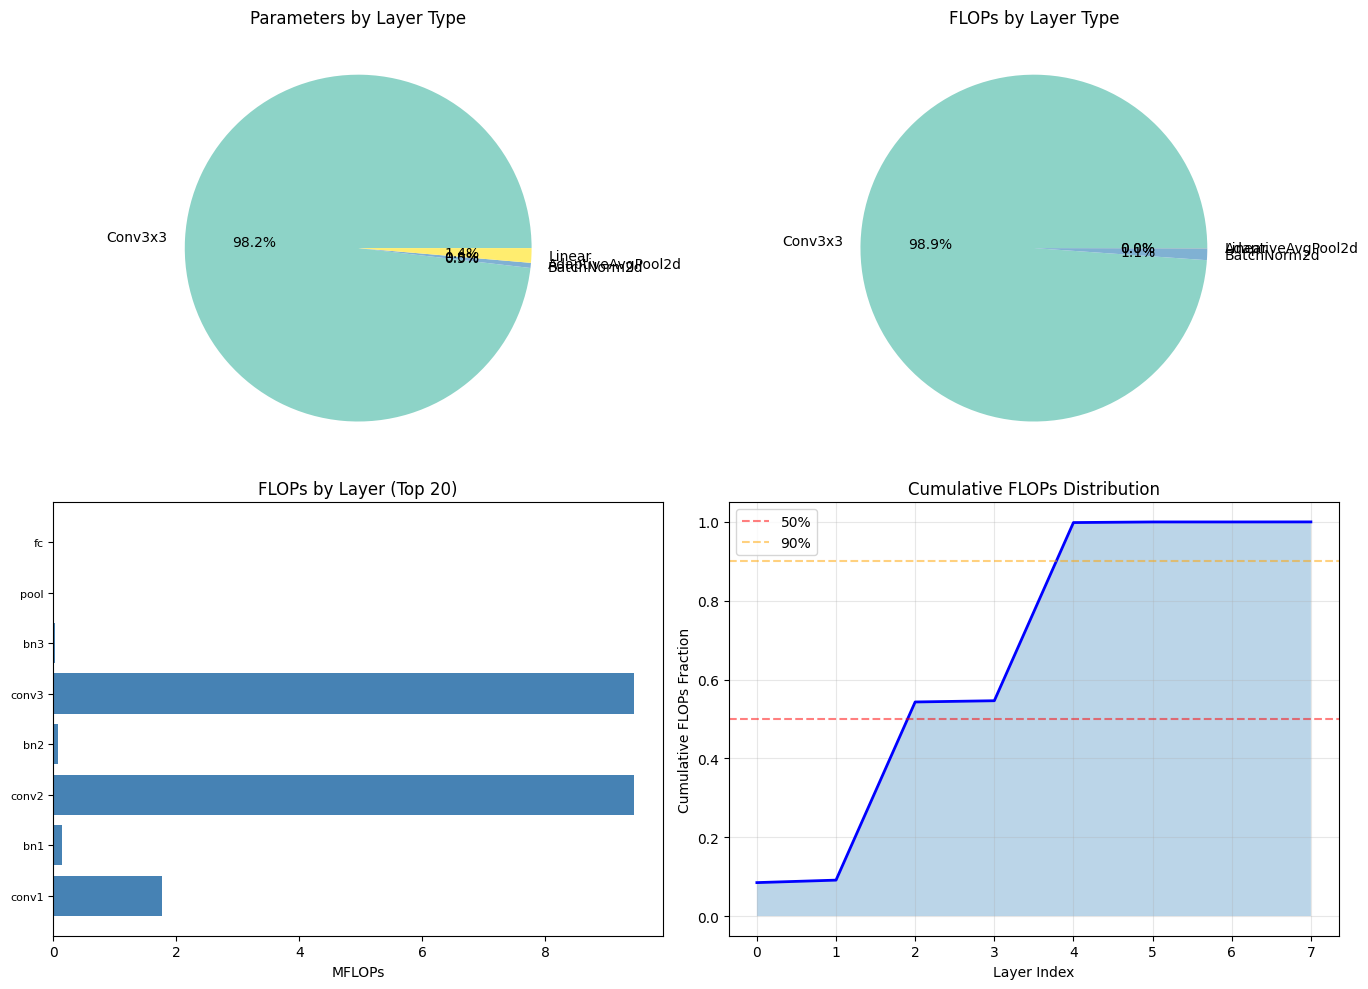

In [6]:
# Analyze SimpleNet

analyzer = LayerAnalyzer(profiler)

print("Top FLOPs Consumers:")
bottlenecks = analyzer.find_bottlenecks('flops', top_k=5)
for i, layer in enumerate(bottlenecks, 1):
    print(f"  {i}. {layer.name} ({layer.layer_type}): {layer.flops:,} FLOPs")

print("\nEfficiency Ratios (FLOPs/Param):")
ratios = analyzer.compute_efficiency_ratio()
for layer_type, ratio in sorted(ratios.items(), key=lambda x: x[1], reverse=True):
    print(f"  {layer_type}: {ratio:.1f}")

analyzer.visualize_distribution('layer_distribution.png')

 Memory Profiling

Analyze memory usage patterns during forward and backward passes.

In [7]:
class MemoryProfiler:
    """
    Profile memory usage of a model.

    Tracks:
    - Parameter memory
    - Activation memory
    - Gradient memory
    - Peak memory
    """

    def __init__(self, model: nn.Module):
        self.model = model

    def get_parameter_memory(self) -> float:
        """Get memory for parameters (MB)."""
        total_bytes = sum(p.numel() * p.element_size() for p in self.model.parameters())
        return total_bytes / (1024 ** 2)

    def get_buffer_memory(self) -> float:
        """Get memory for buffers (MB)."""
        total_bytes = sum(b.numel() * b.element_size() for b in self.model.buffers())
        return total_bytes / (1024 ** 2)

    def estimate_activation_memory(self, input_size: Tuple[int, ...]) -> float:
        """
        Estimate activation memory during forward pass.
        """
        activation_sizes = []
        hooks = []

        def hook_fn(module, input, output):
            if isinstance(output, torch.Tensor):
                activation_sizes.append(output.numel() * output.element_size())

        for module in self.model.modules():
            hooks.append(module.register_forward_hook(hook_fn))

        x = torch.randn(input_size)
        self.model.eval()
        with torch.no_grad():
            _ = self.model(x)

        for h in hooks:
            h.remove()

        return sum(activation_sizes) / (1024 ** 2)

    def estimate_gradient_memory(self) -> float:
        """
        Estimate gradient memory (same as parameters for SGD).
        """
        return self.get_parameter_memory()

    def estimate_optimizer_memory(self, optimizer_type: str = 'adam') -> float:
        """
        Estimate optimizer state memory.
        """
        param_memory = self.get_parameter_memory()

        if optimizer_type.lower() == 'sgd':
            return 0  # No extra state
        elif optimizer_type.lower() == 'sgd_momentum':
            return param_memory  # Momentum buffer
        elif optimizer_type.lower() == 'adam':
            return 2 * param_memory  # m and v buffers
        else:
            return param_memory

    def full_memory_report(self, input_size: Tuple[int, ...],
                           batch_size: int = 32,
                           optimizer: str = 'adam') -> Dict[str, float]:
        """
        Generate full memory report.
        """
        # Scale input for batch size
        batched_input = (batch_size,) + input_size[1:]

        param_mem = self.get_parameter_memory()
        buffer_mem = self.get_buffer_memory()
        activation_mem = self.estimate_activation_memory(batched_input)
        gradient_mem = self.estimate_gradient_memory()
        optimizer_mem = self.estimate_optimizer_memory(optimizer)

        total_inference = param_mem + buffer_mem + activation_mem
        total_training = total_inference + gradient_mem + optimizer_mem

        return {
            'parameters_mb': param_mem,
            'buffers_mb': buffer_mem,
            'activations_mb': activation_mem,
            'gradients_mb': gradient_mem,
            'optimizer_mb': optimizer_mem,
            'total_inference_mb': total_inference,
            'total_training_mb': total_training
        }

In [8]:
# Memory analysis

mem_profiler = MemoryProfiler(model)
report = mem_profiler.full_memory_report((1, 3, 32, 32), batch_size=64)

print("Memory Report (batch_size=64)")
print("=" * 40)
for key, value in report.items():
    print(f"{key:<25}: {value:>8.2f} MB")

Memory Report (batch_size=64)
parameters_mb            :     0.36 MB
buffers_mb               :     0.00 MB
activations_mb           :    28.04 MB
gradients_mb             :     0.36 MB
optimizer_mb             :     0.72 MB
total_inference_mb       :    28.40 MB
total_training_mb        :    29.49 MB


Latency & Throughput

Measure actual inference speed.

In [9]:
class LatencyProfiler:
    """
    Profile inference latency and throughput.
    """

    def __init__(self, model: nn.Module, device: torch.device = device):
        self.model = model.to(device)
        self.device = device

    def measure_latency(self, input_size: Tuple[int, ...],
                        num_warmup: int = 10,
                        num_iterations: int = 100) -> Dict[str, float]:
        """
        Measure inference latency.
        """
        self.model.eval()
        x = torch.randn(input_size).to(self.device)

        # Warmup
        with torch.no_grad():
            for _ in range(num_warmup):
                _ = self.model(x)

        # Synchronize if CUDA
        if self.device.type == 'cuda':
            torch.cuda.synchronize()

        # Measure
        latencies = []
        with torch.no_grad():
            for _ in range(num_iterations):
                start = time.perf_counter()
                _ = self.model(x)

                if self.device.type == 'cuda':
                    torch.cuda.synchronize()

                latencies.append((time.perf_counter() - start) * 1000)  # ms

        return {
            'mean_ms': np.mean(latencies),
            'std_ms': np.std(latencies),
            'min_ms': np.min(latencies),
            'max_ms': np.max(latencies),
            'p50_ms': np.percentile(latencies, 50),
            'p95_ms': np.percentile(latencies, 95),
            'p99_ms': np.percentile(latencies, 99)
        }

    def measure_throughput(self, input_size: Tuple[int, ...],
                           batch_sizes: List[int] = [1, 8, 16, 32, 64],
                           num_iterations: int = 50) -> Dict[int, float]:
        """
        Measure throughput at different batch sizes.
        """
        self.model.eval()
        results = {}

        for batch_size in batch_sizes:
            batched_size = (batch_size,) + input_size[1:]
            x = torch.randn(batched_size).to(self.device)

            # Warmup
            with torch.no_grad():
                for _ in range(5):
                    _ = self.model(x)

            if self.device.type == 'cuda':
                torch.cuda.synchronize()

            # Measure
            start = time.perf_counter()
            with torch.no_grad():
                for _ in range(num_iterations):
                    _ = self.model(x)

            if self.device.type == 'cuda':
                torch.cuda.synchronize()

            elapsed = time.perf_counter() - start
            throughput = (batch_size * num_iterations) / elapsed
            results[batch_size] = throughput

        return results

    def layer_latency_breakdown(self, input_size: Tuple[int, ...],
                                 num_iterations: int = 20) -> Dict[str, float]:
        """
        Measure latency contribution of each layer.
        """
        self.model.eval()
        layer_times = defaultdict(list)
        hooks = []

        def make_hook(name):
            def hook(module, input, output):
                if self.device.type == 'cuda':
                    torch.cuda.synchronize()
                layer_times[name].append(time.perf_counter())
            return hook

        # Register hooks
        prev_name = None
        for name, module in self.model.named_modules():
            if len(list(module.children())) == 0:
                hooks.append(module.register_forward_hook(make_hook(name)))

        # Measure
        x = torch.randn(input_size).to(self.device)

        with torch.no_grad():
            for _ in range(num_iterations):
                _ = self.model(x)

        # Remove hooks
        for h in hooks:
            h.remove()

        # Compute layer latencies (differences between timestamps)
        layer_latencies = {}
        names = list(layer_times.keys())

        for i in range(len(names) - 1):
            times_curr = np.array(layer_times[names[i]])
            times_next = np.array(layer_times[names[i + 1]])

            # Average latency in ms
            if len(times_curr) == len(times_next):
                latency = np.mean(times_next - times_curr) * 1000
                layer_latencies[names[i]] = latency

        return layer_latencies

In [10]:
# Latency profiling

lat_profiler = LatencyProfiler(model)

print("Latency Analysis")
print("=" * 50)

latency = lat_profiler.measure_latency((1, 3, 32, 32))
print("\nSingle Sample Latency:")
for key, value in latency.items():
    print(f"  {key}: {value:.3f}")

print("\nThroughput at Different Batch Sizes:")
throughput = lat_profiler.measure_throughput((1, 3, 32, 32))
for batch_size, tp in throughput.items():
    print(f"  Batch {batch_size:>3}: {tp:>8.1f} samples/sec")

Latency Analysis

Single Sample Latency:
  mean_ms: 1.052
  std_ms: 0.071
  min_ms: 0.998
  max_ms: 1.561
  p50_ms: 1.030
  p95_ms: 1.157
  p99_ms: 1.254

Throughput at Different Batch Sizes:
  Batch   1:    914.4 samples/sec
  Batch   8:   1611.3 samples/sec
  Batch  16:    817.3 samples/sec
  Batch  32:   1047.1 samples/sec
  Batch  64:   1239.7 samples/sec


Efficiency Metrics

Compute comprehensive efficiency metrics.

In [11]:
def evaluate_accuracy(model: nn.Module, dataloader: DataLoader,
                      device: torch.device = device) -> Tuple[float, float]:
    """
    Evaluate model accuracy.

    Returns:
        (top1_accuracy, top5_accuracy)
    """
    model.eval()
    model = model.to(device)

    correct_1 = 0
    correct_5 = 0
    total = 0

    with torch.no_grad():
        for data, target in dataloader:
            data, target = data.to(device), target.to(device)
            output = model(data)

            # Top-1
            pred_1 = output.argmax(dim=1)
            correct_1 += pred_1.eq(target).sum().item()

            # Top-5
            _, pred_5 = output.topk(min(5, output.size(1)), dim=1)
            correct_5 += pred_5.eq(target.view(-1, 1)).any(dim=1).sum().item()

            total += target.size(0)

    return correct_1 / total, correct_5 / total


class EfficiencyEvaluator:
    """
    Complete efficiency evaluation suite.
    """

    def __init__(self, dataloader: DataLoader = None):
        self.dataloader = dataloader

    def evaluate(self, model: nn.Module, name: str,
                 input_size: Tuple[int, ...] = (1, 3, 32, 32)) -> EfficiencyMetrics:
        """
        Complete evaluation of model efficiency.
        """
        metrics = EfficiencyMetrics(name=name)

        # Architecture profiling
        arch_profiler = ArchitectureProfiler(model, input_size)
        arch_metrics = arch_profiler.profile()

        metrics.params = arch_metrics.params
        metrics.params_mb = arch_metrics.params_mb
        metrics.flops = arch_metrics.flops
        metrics.macs = arch_metrics.macs
        metrics.activation_memory_mb = arch_metrics.activation_memory_mb

        # Memory profiling
        mem_profiler = MemoryProfiler(model)
        mem_report = mem_profiler.full_memory_report(input_size, batch_size=1)
        metrics.peak_memory_mb = mem_report['total_inference_mb']

        # Latency profiling
        lat_profiler = LatencyProfiler(model)
        latency = lat_profiler.measure_latency(input_size)
        metrics.latency_ms = latency['mean_ms']

        throughput = lat_profiler.measure_throughput(input_size, batch_sizes=[32])
        metrics.throughput = throughput.get(32, 0)

        # Accuracy (if dataloader provided)
        if self.dataloader is not None:
            top1, top5 = evaluate_accuracy(model, self.dataloader)
            metrics.accuracy = top1
            metrics.top5_accuracy = top5

        # Compute derived metrics
        metrics.compute_derived()

        return metrics

    def compare(self, models: Dict[str, nn.Module],
                input_size: Tuple[int, ...] = (1, 3, 32, 32)) -> Dict[str, EfficiencyMetrics]:
        """
        Compare multiple models.
        """
        results = {}

        for name, model in models.items():
            print(f"Evaluating {name}...")
            results[name] = self.evaluate(model, name, input_size)

        return results

 Architecture Comparison

Compare different architectures systematically.

In [12]:
# Define architectures to compare

class MobileNetV1Block(nn.Module):
    """Depthwise separable conv block."""
    def __init__(self, in_c, out_c, stride=1):
        super().__init__()
        self.dw = nn.Conv2d(in_c, in_c, 3, stride, 1, groups=in_c, bias=False)
        self.bn1 = nn.BatchNorm2d(in_c)
        self.pw = nn.Conv2d(in_c, out_c, 1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_c)

    def forward(self, x):
        x = F.relu(self.bn1(self.dw(x)))
        x = F.relu(self.bn2(self.pw(x)))
        return x


class MobileNetV2Block(nn.Module):
    """Inverted residual block."""
    def __init__(self, in_c, out_c, stride=1, expand=6):
        super().__init__()
        hidden = in_c * expand
        self.use_res = stride == 1 and in_c == out_c

        self.expand = nn.Sequential(
            nn.Conv2d(in_c, hidden, 1, bias=False),
            nn.BatchNorm2d(hidden),
            nn.ReLU6(inplace=True)
        ) if expand != 1 else nn.Identity()

        self.dw = nn.Sequential(
            nn.Conv2d(hidden, hidden, 3, stride, 1, groups=hidden, bias=False),
            nn.BatchNorm2d(hidden),
            nn.ReLU6(inplace=True)
        )

        self.project = nn.Sequential(
            nn.Conv2d(hidden, out_c, 1, bias=False),
            nn.BatchNorm2d(out_c)
        )

    def forward(self, x):
        out = self.expand(x) if not isinstance(self.expand, nn.Identity) else x
        out = self.dw(out)
        out = self.project(out)
        return out + x if self.use_res else out


def create_comparison_models():
    """Create models for comparison."""

    # Standard CNN
    class StandardCNN(nn.Module):
        def __init__(self):
            super().__init__()
            self.features = nn.Sequential(
                nn.Conv2d(3, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
                nn.Conv2d(32, 64, 3, stride=2, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
                nn.Conv2d(64, 128, 3, stride=2, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
                nn.Conv2d(128, 256, 3, stride=2, padding=1), nn.BatchNorm2d(256), nn.ReLU(),
            )
            self.pool = nn.AdaptiveAvgPool2d(1)
            self.fc = nn.Linear(256, 10)

        def forward(self, x):
            x = self.features(x)
            x = self.pool(x).flatten(1)
            return self.fc(x)

    # MobileNet-style
    class MobileNetStyle(nn.Module):
        def __init__(self):
            super().__init__()
            self.stem = nn.Sequential(
                nn.Conv2d(3, 32, 3, stride=1, padding=1, bias=False),
                nn.BatchNorm2d(32), nn.ReLU()
            )
            self.features = nn.Sequential(
                MobileNetV1Block(32, 64),
                MobileNetV1Block(64, 128, stride=2),
                MobileNetV1Block(128, 128),
                MobileNetV1Block(128, 256, stride=2),
                MobileNetV1Block(256, 256),
            )
            self.pool = nn.AdaptiveAvgPool2d(1)
            self.fc = nn.Linear(256, 10)

        def forward(self, x):
            x = self.stem(x)
            x = self.features(x)
            x = self.pool(x).flatten(1)
            return self.fc(x)

    # MobileNetV2-style
    class MobileNetV2Style(nn.Module):
        def __init__(self):
            super().__init__()
            self.stem = nn.Sequential(
                nn.Conv2d(3, 32, 3, stride=1, padding=1, bias=False),
                nn.BatchNorm2d(32), nn.ReLU6()
            )
            self.features = nn.Sequential(
                MobileNetV2Block(32, 16, expand=1),
                MobileNetV2Block(16, 24, stride=2),
                MobileNetV2Block(24, 24),
                MobileNetV2Block(24, 32, stride=2),
                MobileNetV2Block(32, 32),
                MobileNetV2Block(32, 64, stride=2),
                MobileNetV2Block(64, 64),
            )
            self.pool = nn.AdaptiveAvgPool2d(1)
            self.fc = nn.Linear(64, 10)

        def forward(self, x):
            x = self.stem(x)
            x = self.features(x)
            x = self.pool(x).flatten(1)
            return self.fc(x)

    # Small efficient model
    class TinyNet(nn.Module):
        def __init__(self):
            super().__init__()
            self.features = nn.Sequential(
                nn.Conv2d(3, 16, 3, padding=1, bias=False),
                nn.BatchNorm2d(16), nn.ReLU(),
                nn.MaxPool2d(2),
                nn.Conv2d(16, 32, 3, padding=1, bias=False),
                nn.BatchNorm2d(32), nn.ReLU(),
                nn.MaxPool2d(2),
                nn.Conv2d(32, 64, 3, padding=1, bias=False),
                nn.BatchNorm2d(64), nn.ReLU(),
            )
            self.pool = nn.AdaptiveAvgPool2d(1)
            self.fc = nn.Linear(64, 10)

        def forward(self, x):
            x = self.features(x)
            x = self.pool(x).flatten(1)
            return self.fc(x)

    return {
        'StandardCNN': StandardCNN(),
        'MobileNetV1': MobileNetStyle(),
        'MobileNetV2': MobileNetV2Style(),
        'TinyNet': TinyNet(),
    }

In [13]:
# Compare architectures

print("=" * 70)
print("ARCHITECTURE COMPARISON")
print("=" * 70)

models = create_comparison_models()
evaluator = EfficiencyEvaluator()

results = evaluator.compare(models, input_size=(1, 3, 32, 32))

# Print comparison table
print(f"\n{'Model':<15} {'Params':>10} {'MFLOPs':>10} {'Memory':>10} {'Latency':>10}")
print("-" * 60)

for name, m in results.items():
    print(f"{name:<15} {m.params/1000:>9.1f}K {m.flops/1e6:>9.2f} "
          f"{m.peak_memory_mb:>9.2f}MB {m.latency_ms:>9.3f}ms")

ARCHITECTURE COMPARISON
Evaluating StandardCNN...
Evaluating MobileNetV1...
Evaluating MobileNetV2...
Evaluating TinyNet...

Model               Params     MFLOPs     Memory    Latency
------------------------------------------------------------
StandardCNN         391.9K     30.33      2.22MB     1.530ms
MobileNetV1         136.8K     34.26      3.78MB     4.465ms
MobileNetV2         116.6K     21.20      6.50MB     4.306ms
TinyNet              24.3K      5.72      0.46MB     0.810ms


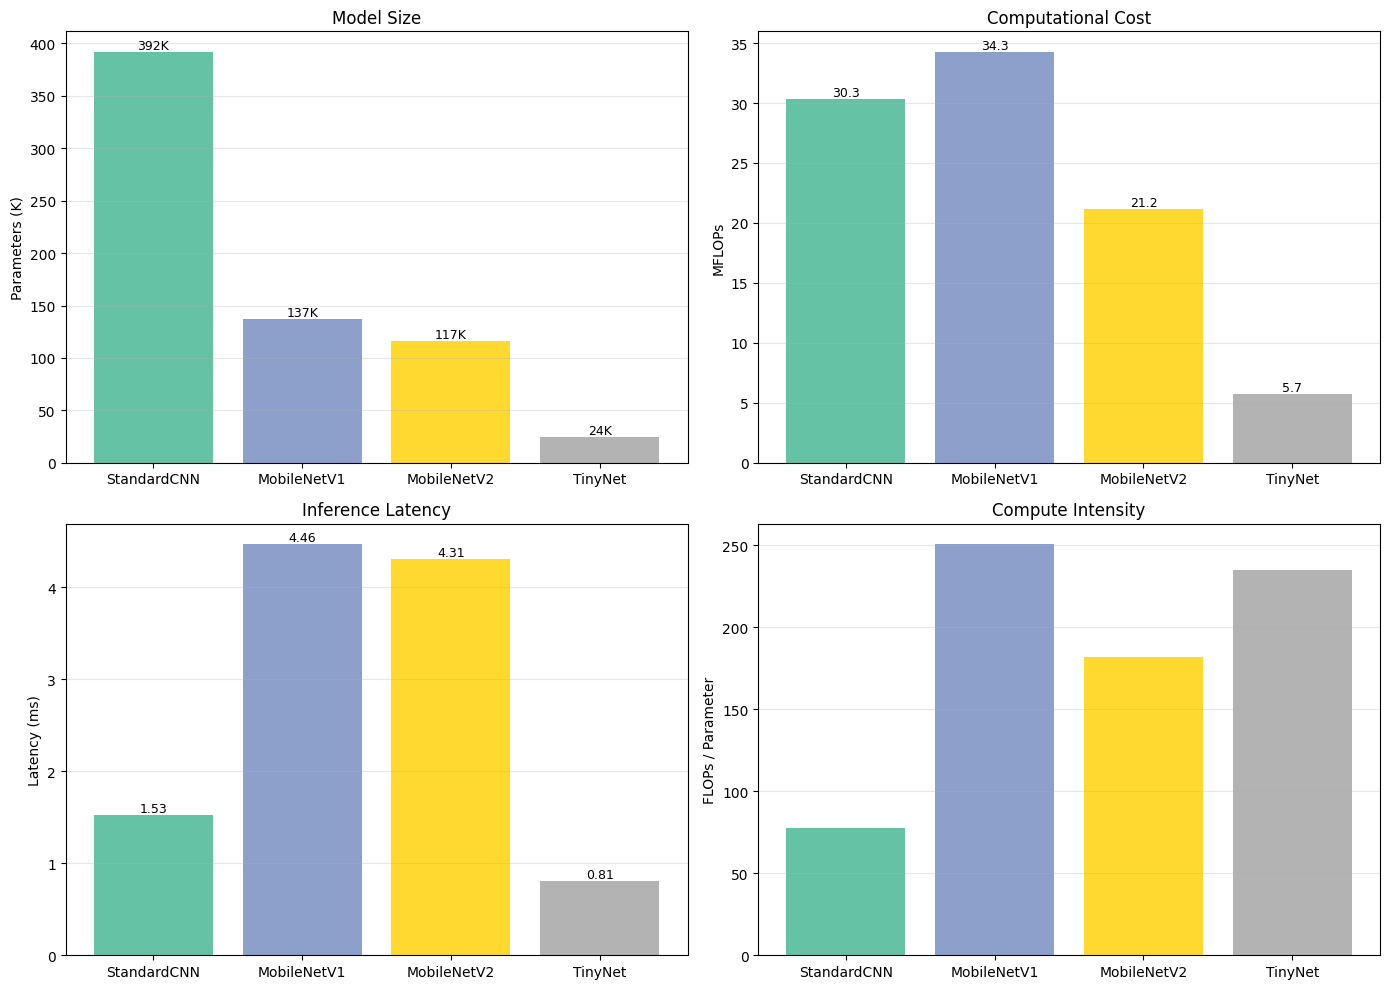

In [14]:
# Visualize comparison

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

names = list(results.keys())
colors = plt.cm.Set2(np.linspace(0, 1, len(names)))

# Plot 1: Parameters
ax = axes[0, 0]
params = [results[n].params / 1000 for n in names]
ax.bar(names, params, color=colors)
ax.set_ylabel('Parameters (K)')
ax.set_title('Model Size')
ax.grid(True, alpha=0.3, axis='y')
for i, p in enumerate(params):
    ax.text(i, p, f'{p:.0f}K', ha='center', va='bottom', fontsize=9)

# Plot 2: FLOPs
ax = axes[0, 1]
flops = [results[n].flops / 1e6 for n in names]
ax.bar(names, flops, color=colors)
ax.set_ylabel('MFLOPs')
ax.set_title('Computational Cost')
ax.grid(True, alpha=0.3, axis='y')
for i, f in enumerate(flops):
    ax.text(i, f, f'{f:.1f}', ha='center', va='bottom', fontsize=9)

# Plot 3: Latency
ax = axes[1, 0]
latencies = [results[n].latency_ms for n in names]
ax.bar(names, latencies, color=colors)
ax.set_ylabel('Latency (ms)')
ax.set_title('Inference Latency')
ax.grid(True, alpha=0.3, axis='y')
for i, l in enumerate(latencies):
    ax.text(i, l, f'{l:.2f}', ha='center', va='bottom', fontsize=9)

# Plot 4: Efficiency (FLOPs/Param)
ax = axes[1, 1]
efficiency = [results[n].flops / results[n].params for n in names]
ax.bar(names, efficiency, color=colors)
ax.set_ylabel('FLOPs / Parameter')
ax.set_title('Compute Intensity')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('architecture_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

Efficiency Frontiers

Visualize Pareto-optimal trade-offs.

In [15]:
class EfficiencyFrontier:
    """
    Compute and visualize efficiency frontiers.
    """

    def __init__(self, metrics: Dict[str, EfficiencyMetrics]):
        self.metrics = metrics

    def find_pareto_frontier(self, x_metric: str, y_metric: str,
                             x_minimize: bool = True,
                             y_maximize: bool = True) -> List[str]:
        """
        Find Pareto-optimal models.
        """
        points = []
        for name, m in self.metrics.items():
            x = getattr(m, x_metric)
            y = getattr(m, y_metric)
            points.append((name, x, y))

        # Sort by x
        points.sort(key=lambda p: p[1], reverse=not x_minimize)

        pareto = []
        best_y = float('-inf') if y_maximize else float('inf')

        for name, x, y in points:
            if y_maximize:
                if y > best_y:
                    pareto.append(name)
                    best_y = y
            else:
                if y < best_y:
                    pareto.append(name)
                    best_y = y

        return pareto

    def plot_frontier(self, x_metric: str, y_metric: str,
                      x_label: str = None, y_label: str = None,
                      title: str = None, save_path: str = None):
        """
        Plot efficiency frontier.
        """
        fig, ax = plt.subplots(figsize=(10, 6))

        x_vals = [getattr(m, x_metric) for m in self.metrics.values()]
        y_vals = [getattr(m, y_metric) for m in self.metrics.values()]
        names = list(self.metrics.keys())

        colors = plt.cm.Set2(np.linspace(0, 1, len(names)))

        # Plot all points
        for i, (name, x, y) in enumerate(zip(names, x_vals, y_vals)):
            ax.scatter(x, y, s=200, c=[colors[i]], edgecolors='black',
                      linewidth=2, label=name, zorder=5)

        # Find and highlight Pareto frontier
        pareto = self.find_pareto_frontier(x_metric, y_metric)
        pareto_x = [getattr(self.metrics[n], x_metric) for n in pareto]
        pareto_y = [getattr(self.metrics[n], y_metric) for n in pareto]

        # Sort for line
        sorted_points = sorted(zip(pareto_x, pareto_y))
        if sorted_points:
            ax.plot([p[0] for p in sorted_points], [p[1] for p in sorted_points],
                   'r--', linewidth=2, alpha=0.7, label='Pareto Frontier')

        ax.set_xlabel(x_label or x_metric)
        ax.set_ylabel(y_label or y_metric)
        ax.set_title(title or f'{y_metric} vs {x_metric}')
        ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        ax.grid(True, alpha=0.3)

        plt.tight_layout()
        if save_path:
            plt.savefig(save_path, dpi=150, bbox_inches='tight')
        plt.show()

        return pareto

Efficiency Frontiers


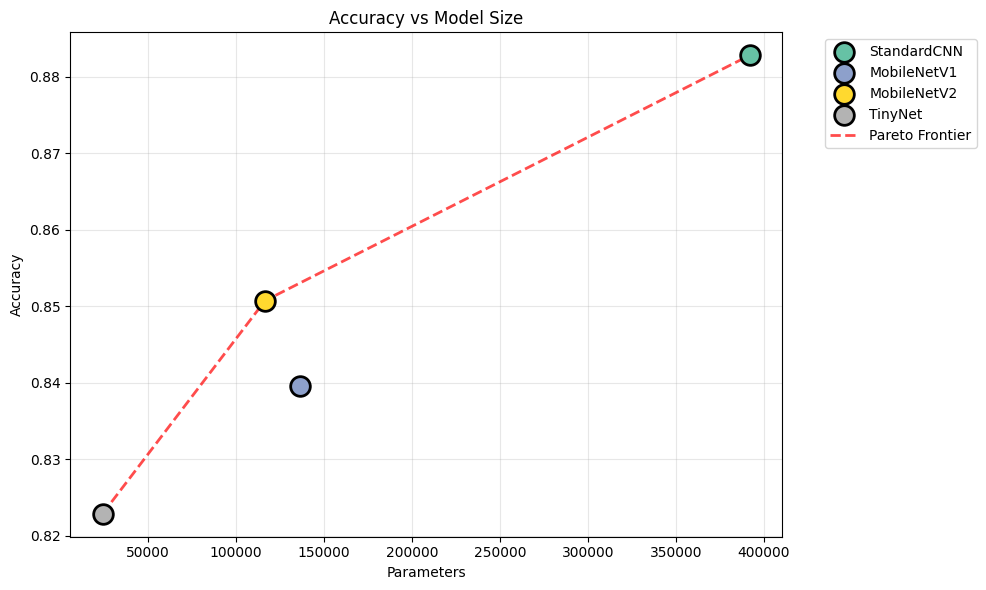

Pareto-optimal (Params vs Acc): ['TinyNet', 'MobileNetV2', 'StandardCNN']


In [16]:
# Simulate accuracy for visualization
# In practice, this would come from actual evaluation

for name, m in results.items():
    # Simulate: larger models tend to have higher accuracy
    m.accuracy = 0.5 + 0.4 * np.log10(m.params + 1) / 6 + np.random.normal(0, 0.02)
    m.accuracy = min(0.95, max(0.5, m.accuracy))
    m.compute_derived()

# Create frontier analyzer
frontier = EfficiencyFrontier(results)

# Plot different frontiers
print("Efficiency Frontiers")
print("=" * 50)

pareto = frontier.plot_frontier(
    'params', 'accuracy',
    x_label='Parameters',
    y_label='Accuracy',
    title='Accuracy vs Model Size',
    save_path='frontier_params_acc.png'
)
print(f"Pareto-optimal (Params vs Acc): {pareto}")

In [17]:
# Generate comprehensive efficiency report

def generate_efficiency_report(results: Dict[str, EfficiencyMetrics],
                               save_path: str = 'efficiency_report.txt'):
    """
    Generate comprehensive efficiency report.
    """
    report = []
    report.append("=" * 80)
    report.append("ARCHITECTURE EFFICIENCY REPORT")
    report.append("=" * 80)
    report.append("")

    # Summary table
    report.append("SUMMARY")
    report.append("-" * 80)
    report.append(f"{'Model':<15} {'Params':>10} {'FLOPs':>10} {'Memory':>10} "
                 f"{'Latency':>10} {'Accuracy':>10}")
    report.append("-" * 80)

    for name, m in results.items():
        report.append(f"{name:<15} {m.params/1000:>9.1f}K {m.flops/1e6:>9.2f}M "
                     f"{m.peak_memory_mb:>9.2f}MB {m.latency_ms:>9.3f}ms "
                     f"{100*m.accuracy:>9.1f}%")

    report.append("")

    # Efficiency metrics
    report.append("EFFICIENCY METRICS")
    report.append("-" * 80)
    report.append(f"{'Model':<15} {'Acc/Param':>12} {'Acc/GFLOP':>12} {'Acc/ms':>12}")
    report.append("-" * 80)

    for name, m in results.items():
        report.append(f"{name:<15} {m.accuracy_per_param:>12.4f} "
                     f"{m.accuracy_per_flop:>12.4f} {m.accuracy_per_ms:>12.4f}")

    report.append("")

    # Rankings
    report.append("RANKINGS")
    report.append("-" * 80)

    metrics_to_rank = [
        ('Smallest', 'params', False),
        ('Fastest', 'latency_ms', False),
        ('Most Accurate', 'accuracy', True),
        ('Most Param-Efficient', 'accuracy_per_param', True),
    ]

    for label, metric, reverse in metrics_to_rank:
        sorted_models = sorted(results.items(),
                              key=lambda x: getattr(x[1], metric),
                              reverse=reverse)
        winner = sorted_models[0][0]
        report.append(f"{label}: {winner}")

    report.append("")
    report.append("=" * 80)

    # Print and save
    report_text = "\n".join(report)
    print(report_text)

    with open(save_path, 'w') as f:
        f.write(report_text)

    return report_text

# Generate report
report = generate_efficiency_report(results)

ARCHITECTURE EFFICIENCY REPORT

SUMMARY
--------------------------------------------------------------------------------
Model               Params      FLOPs     Memory    Latency   Accuracy
--------------------------------------------------------------------------------
StandardCNN         391.9K     30.33M      2.22MB     1.530ms      88.3%
MobileNetV1         136.8K     34.26M      3.78MB     4.465ms      84.0%
MobileNetV2         116.6K     21.20M      6.50MB     4.306ms      85.1%
TinyNet              24.3K      5.72M      0.46MB     0.810ms      82.3%

EFFICIENCY METRICS
--------------------------------------------------------------------------------
Model              Acc/Param    Acc/GFLOP       Acc/ms
--------------------------------------------------------------------------------
StandardCNN           2.2524      29.1052       0.5771
MobileNetV1           6.1387      24.5049       0.1880
MobileNetV2           7.2951      40.1328       0.1976
TinyNet              33.7998     